# Explore `train.pt` / `test.pt`

Synthetic heat-equation dataset: **boundaries**, full **trajectories** `[N, T, H, W]`, and optionally **`u_final_solve`** at solve resolution.

Run from repo root or set `REPO_ROOT` below.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Project root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "outputs" / "data"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /Users/zachrobers/Coursework/Duke/Computer Science/CS590/heat_operator_recovery/outputs/data


In [10]:
def load_split(name: str) -> dict:
    path = DATA_DIR / f"{name}.pt"
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}")
    return torch.load(path, map_location="cpu")


train = load_split("train")
print("Keys:", list(train.keys()))
print()
for k, v in train.items():
    if k == "meta":
        print("meta:", v)
    else:
        print(f"{k}: shape={tuple(v.shape)} dtype={v.dtype}")

Keys: ['boundaries', 'trajectories', 'u_final_solve', 'meta']

boundaries: shape=(32, 32, 32) dtype=torch.float32
trajectories: shape=(32, 501, 32, 32) dtype=torch.float32
u_final_solve: shape=(32, 96, 96) dtype=torch.float32
meta: {'grid_size': 32, 'solve_grid_size': 96, 'final_grid_size': 96, 'num_pde_steps': 20, 'kappa': 0.1, 'boundary_mode': 'fourier', 'solve': {'dt': 0.0011706555671175858, 'solve_grid_size': 32}, 'store_grid_size': 32, 'recomputed_trajectories': True}


## Shapes in words

- **`boundaries`**: one `[H, W]` boundary grid per sample (Dirichlet on edges).
- **`trajectories`**: `[N, T, H, W]` — full evolution; `T = num_pde_steps + 1` (frame 0 is initial field).
- **`u_final_solve`** (if present): `[N, H_solve, W_solve]` — terminal field; may be higher resolution than trajectory slices.

In [11]:
b = train["boundaries"]
traj = train["trajectories"]
N, T, H, W = traj.shape
print(f"Samples: {N}, time frames: {T}, spatial: {H}×{W}")

u_final = train.get("u_final_solve")
if u_final is not None:
    print(f"u_final_solve: {tuple(u_final.shape)} (terminal field at solve grid)")
else:
    print("No u_final_solve in file (older export).")

Samples: 32, time frames: 501, spatial: 32×32
u_final_solve: (32, 96, 96) (terminal field at solve grid)


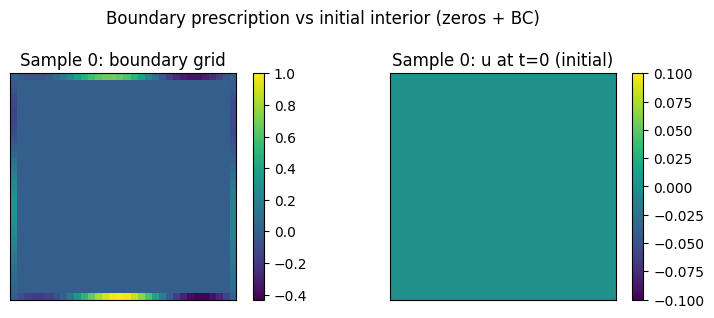

In [12]:
def show_field(ax, u, title: str, cmap="viridis"):
    if isinstance(u, torch.Tensor):
        u = u.detach().numpy()
    im = ax.imshow(u, origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)


idx = 0
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
show_field(axes[0], b[idx], f"Sample {idx}: boundary grid")
show_field(axes[1], traj[idx, 0], f"Sample {idx}: u at t=0 (initial)")
fig.suptitle("Boundary prescription vs initial interior (zeros + BC)")
plt.tight_layout()
plt.show()

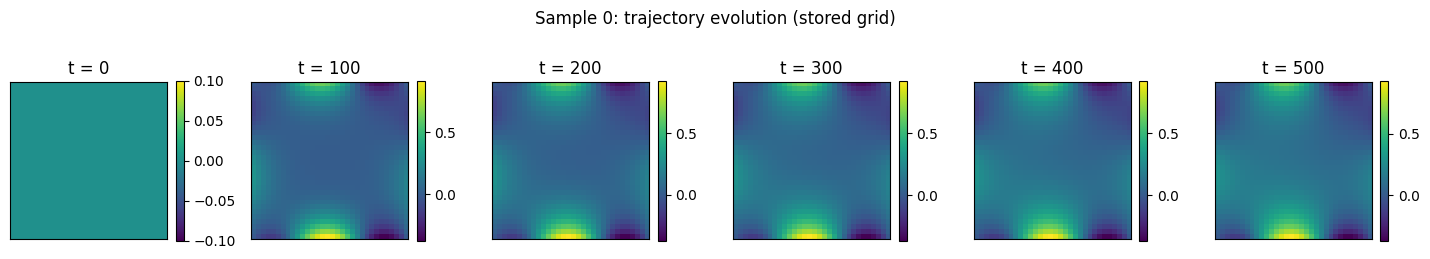

In [13]:
# Same sample: trajectory snapshots in time
times = np.linspace(0, T - 1, num=min(6, T), dtype=int)
ncols = len(times)
fig, axes = plt.subplots(1, ncols, figsize=(2.4 * ncols, 2.8))
if ncols == 1:
    axes = [axes]
for ax, t in zip(axes, times):
    show_field(ax, traj[idx, t], f"t = {t}")
fig.suptitle(f"Sample {idx}: trajectory evolution (stored grid)")
plt.tight_layout()
plt.show()

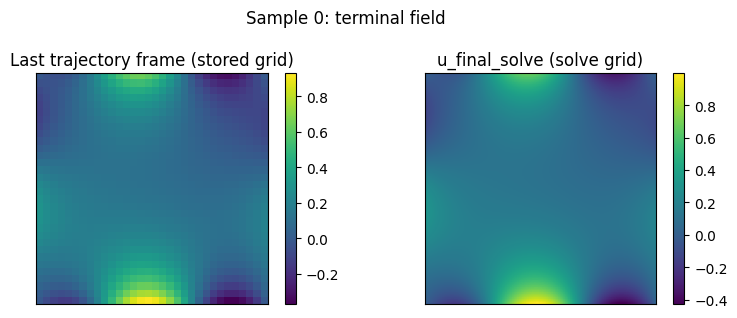

In [14]:
# Last stored frame vs u_final_solve (if different resolution)
u_last = traj[idx, -1]
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
show_field(axes[0], u_last, "Last trajectory frame (stored grid)")
if u_final is not None:
    show_field(axes[1], u_final[idx], "u_final_solve (solve grid)")
else:
    axes[1].axis("off")
    axes[1].set_title("No u_final_solve")
plt.suptitle(f"Sample {idx}: terminal field")
plt.tight_layout()
plt.show()

In [15]:
# Scalar diagnostics over the dataset (interior only, optional)
interior = traj[:, :, 1:-1, 1:-1]
print("trajectory interior — min / max / mean (all samples, all times):")
print(float(interior.min()), float(interior.max()), float(interior.mean()))

edge = torch.cat(
    [traj[:, :, 0, :].reshape(-1), traj[:, :, -1, :].reshape(-1), traj[:, :, 1:-1, 0].reshape(-1), traj[:, :, 1:-1, -1].reshape(-1)]
)
print("boundary pixels (all) — min / max:", float(edge.min()), float(edge.max()))

trajectory interior — min / max / mean (all samples, all times):
-0.8672885894775391 0.8550630807876587 -0.022604454308748245
boundary pixels (all) — min / max: -0.9655812382698059 0.9615052938461304


In [16]:
# Optional: held-out test split (20% by default)
test = load_split("test")
print("test keys:", list(test.keys()))
print("test trajectories:", tuple(test["trajectories"].shape))

val keys: ['boundaries', 'trajectories', 'u_final_solve', 'meta']
val trajectories: (8, 501, 32, 32)
